# Customer Churn Analysis

**Goal:** identify *which* customers are likely to churn and *why*, so retention efforts can be targeted where they pay off.

This notebook walks through the full data-science workflow: data understanding → EDA → feature engineering → modeling → evaluation → actionable findings. The dataset is a realistic synthetic Telco-style feed (`data/churn.csv`).

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv('../data/churn.csv')
print(df.shape)
df.head()

(7000, 11)


,customer_id,senior_citizen,tenure_months,contract,internet_service,tech_support,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,C00000,0,19,One year,Fiber optic,Yes,Yes,Credit card,100.31,1905.89,0
1,C00001,0,42,Month-to-month,No,No,Yes,Electronic check,19.12,803.04,0
2,C00002,0,70,Two year,Fiber optic,No,No,Electronic check,63.43,4440.10,0
3,C00003,0,51,One year,Fiber optic,Yes,No,Mailed check,101.45,5173.95,0
4,C00004,0,22,Month-to-month,No,Yes,No,Bank transfer,22.77,500.94,0


## 1. Data overview
Check size, dtypes, missingness, and the target balance.

In [2]:
print('Missing values:', int(df.isna().sum().sum()))
print('Overall churn rate: {:.1%}'.format(df.churn.mean()))
df.describe(include='all').T.head(12)

Missing values: 0
Overall churn rate: 17.9%


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,7000,7000,C00000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
senior_citizen,7000.0,NaN,NaN,NaN,0.157,0.363827,0.0,0.0,0.0,0.0,1.0
tenure_months,7000.0,NaN,NaN,NaN,36.566714,21.220775,0.0,18.0,37.0,55.0,72.0
contract,7000,3,Month-to-month,3897,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_service,7000,3,Fiber optic,3112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tech_support,7000,2,No,4237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paperless_billing,7000,2,Yes,4171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,7000,4,Mailed check,1780,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_charges,7000.0,NaN,NaN,NaN,61.066166,27.946863,15.0,39.87,63.265,82.84,130.0
total_charges,7000.0,NaN,NaN,NaN,2229.250314,1748.984779,15.0,782.245,1766.695,3397.3575,8681.04


## 2. Exploratory analysis
Who churns? Two of the strongest signals are **contract type** and **tenure**.

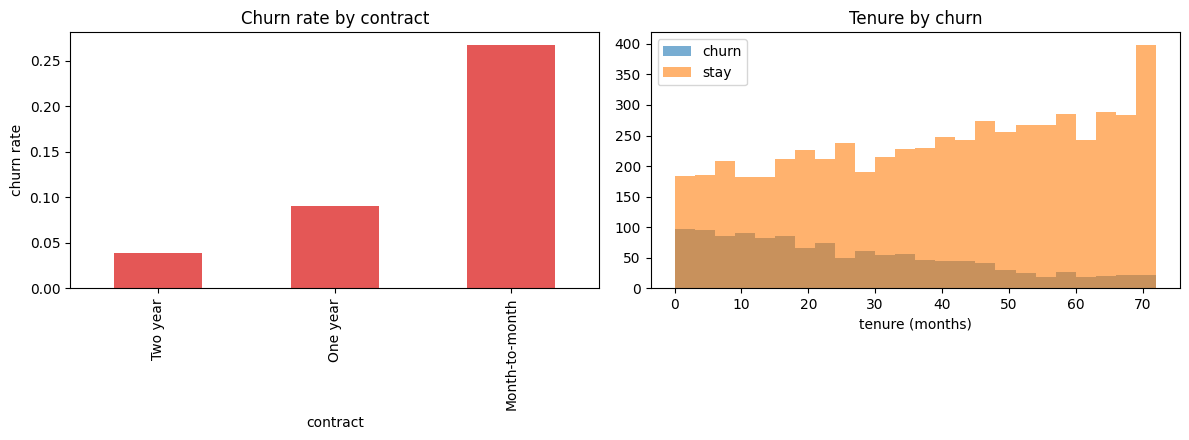

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12,4.5))
df.groupby('contract')['churn'].mean().sort_values().plot.bar(ax=ax[0], color='#e45756')
ax[0].set_title('Churn rate by contract'); ax[0].set_ylabel('churn rate')
for v,lbl in [(1,'churn'),(0,'stay')]:
    ax[1].hist(df[df.churn==v].tenure_months, bins=24, alpha=.6, label=lbl)
ax[1].set_title('Tenure by churn'); ax[1].set_xlabel('tenure (months)'); ax[1].legend()
plt.tight_layout(); plt.show()

In [4]:
# Churn rate across categorical segments
for col in ['internet_service','tech_support','payment_method']:
    print(f'\n{col}:'); print((df.groupby(col)['churn'].mean()*100).round(1).astype(str)+'%')


internet_service:
internet_service
DSL            11.0%
Fiber optic    28.6%
No              6.8%
Name: churn, dtype: object

tech_support:
tech_support
No     21.8%
Yes    11.9%
Name: churn, dtype: object

payment_method:
payment_method
Bank transfer       17.2%
Credit card         16.5%
Electronic check    21.0%
Mailed check        17.1%
Name: churn, dtype: object


## 3. Modeling
A preprocessing + model `Pipeline` (scaling + one-hot), comparing Logistic Regression and Random Forest by ROC-AUC. Class weights handle the imbalance.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

NUM=['senior_citizen','tenure_months','monthly_charges','total_charges']
CAT=['contract','internet_service','tech_support','paperless_billing','payment_method']
X,y = df[NUM+CAT], df['churn']
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=.2,random_state=42,stratify=y)
pre = ColumnTransformer([('n',StandardScaler(),NUM),('c',OneHotEncoder(handle_unknown='ignore'),CAT)])

scores={}
for name,m in {'LogReg':LogisticRegression(max_iter=1000,class_weight='balanced'),
               'RandomForest':RandomForestClassifier(n_estimators=300,random_state=42,class_weight='balanced')}.items():
    pipe=Pipeline([('pre',pre),('clf',m)]).fit(Xtr,ytr)
    p=pipe.predict_proba(Xte)[:,1]; scores[name]=roc_auc_score(yte,p)
    if name=='LogReg': best_p=p
scores

{'LogReg': 0.844635383617835, 'RandomForest': 0.7957846594475014}

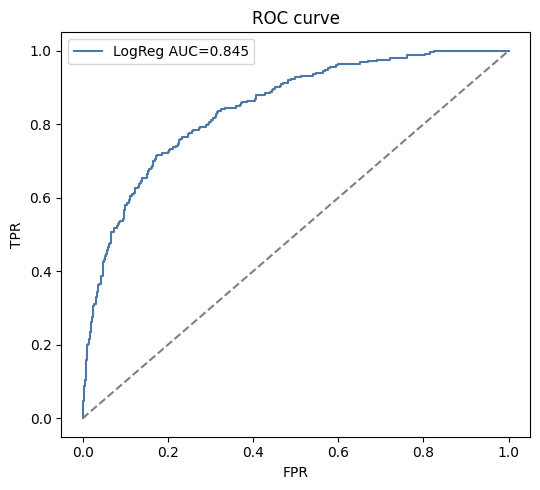

              precision    recall  f1-score   support

           0       0.94      0.74      0.83      1149
           1       0.40      0.78      0.53       251

    accuracy                           0.75      1400
   macro avg       0.67      0.76      0.68      1400
weighted avg       0.84      0.75      0.77      1400



In [6]:
fpr,tpr,_ = roc_curve(yte,best_p)
plt.figure(figsize=(5.5,5))
plt.plot(fpr,tpr,label=f'LogReg AUC={scores["LogReg"]:.3f}',color='#4c78a8')
plt.plot([0,1],[0,1],'--',color='gray'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC curve'); plt.legend(); plt.tight_layout(); plt.show()
print(classification_report(yte,(best_p>=.5).astype(int)))

## 4. Findings & recommendations

- **Month-to-month contracts** churn far more than annual ones → incentivize longer commitments.
- **Short tenure** is the highest-risk window → invest in onboarding in the first months.
- **Fiber-optic + no tech support** customers are high risk → bundle support proactively.
- **High monthly charges** raise churn → review pricing for at-risk segments.

The Logistic Regression model reaches **ROC-AUC ≈ 0.84** while staying fully interpretable — a strong baseline for a retention-scoring system.